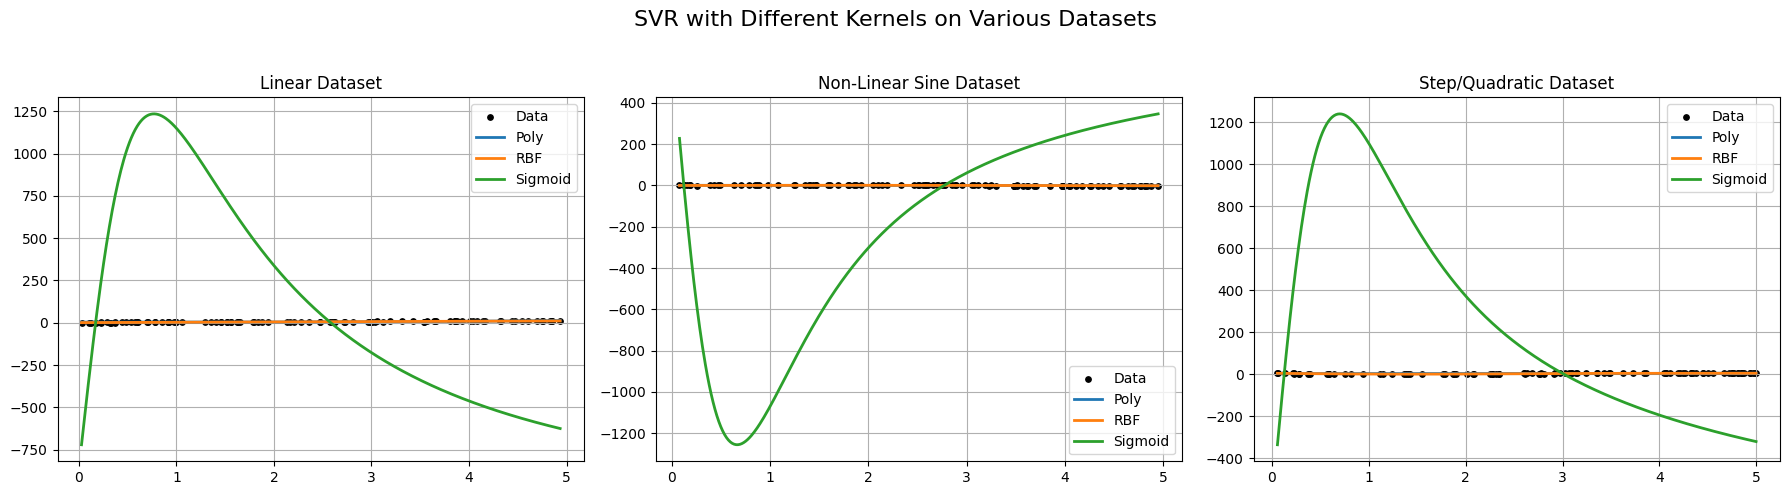

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Helper: Train and plot SVR with 3 kernels on a dataset
def train_and_plot(X, y, title, ax):
    svr_poly = SVR(kernel='poly', degree=3, C=100, epsilon=0.1)
    svr_rbf = SVR(kernel='rbf', gamma=0.1, C=100, epsilon=0.1)
    svr_sigmoid = SVR(kernel='sigmoid', C=100, epsilon=0.1)

    svr_poly.fit(X, y)
    svr_rbf.fit(X, y)
    svr_sigmoid.fit(X, y)

    X_test = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
    y_poly = svr_poly.predict(X_test)
    y_rbf = svr_rbf.predict(X_test)
    y_sigmoid = svr_sigmoid.predict(X_test)

    ax.scatter(X, y, color='black', label='Data', s=15)
    ax.plot(X_test, y_poly, label='Poly', linewidth=2)
    ax.plot(X_test, y_rbf, label='RBF', linewidth=2)
    ax.plot(X_test, y_sigmoid, label='Sigmoid', linewidth=2)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

# Generate 3 datasets
np.random.seed(42)

# Dataset 1: Linear
X1 = np.sort(5 * np.random.rand(100, 1), axis=0)
y1 = 2 * X1.ravel() + 1 + 0.5 * np.random.randn(100)

# Dataset 2: Non-linear (sine wave)
X2 = np.sort(5 * np.random.rand(100, 1), axis=0)
y2 = np.sin(X2).ravel() + 0.2 * np.random.randn(100)

# Dataset 3: Step-like (quadratic)
X3 = np.sort(5 * np.random.rand(100, 1), axis=0)
y3 = np.piecewise(X3.ravel(), [X3.ravel() < 2.5, X3.ravel() >= 2.5], [lambda x: x**2 - 4*x + 4, lambda x: 0.5*x + 2])
y3 += 0.2 * np.random.randn(100)

# Plot all
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

train_and_plot(X1, y1, "Linear Dataset", axs[0])
train_and_plot(X2, y2, "Non-Linear Sine Dataset", axs[1])
train_and_plot(X3, y3, "Step/Quadratic Dataset", axs[2])

plt.suptitle("SVR with Different Kernels on Various Datasets", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
